In [1]:
import h5py
import numpy as np
from scipy import signal
from scipy.signal import welch, csd
import matplotlib.pyplot as plt
from os import listdir
from scipy import fft
import pickle
from datetime import datetime
import sys
import os
# Specify the absolute path to the 'libraries' directory
library_path = r'C:\Users\00103619\GitHub\MAGE-Data-Analysis\MAGE\MAGE4'  # Adjust this to the actual absolute path

# Add the 'libraries' directory to sys.path
sys.path.append(library_path)

# Now you can import utils.py as a module
import Analysis_functions

Open pickle file with events

In [2]:
run=13

folder = r'C:/Users/00103619/MAGE/MAGE4/Analysis/run13-Teff'
harddisk_fold= r'C:/Users/00103619/MAGE/MAGE4/run13'
file_metainfo = 'run13-1.hdf5'

with open(folder + '\event_catalogue-pub' +'.pkl', 'rb') as f:
    event_catalogue = pickle.load(f)
    
with open(folder + '\co_event_strain-pub' +'.pkl', 'rb') as f:
    co_events = pickle.load(f)

Ninputs, Nchannels, Nsamples, Fs, dt, fdemods, t_start = Analysis_functions.get_meta_data_from_first_file(harddisk_fold + "/" + file_metainfo) 

<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:10: SyntaxWarning: invalid escape sequence '\c'
<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:10: SyntaxWarning: invalid escape sequence '\c'
C:\Users\00103619\AppData\Local\Temp\ipykernel_19600\13721798.py:7: SyntaxWarning: invalid escape sequence '\e'
  with open(folder + '\event_catalogue-pub' +'.pkl', 'rb') as f:
C:\Users\00103619\AppData\Local\Temp\ipykernel_19600\13721798.py:10: SyntaxWarning: invalid escape sequence '\c'
  with open(folder + '\co_event_strain-pub' +'.pkl', 'rb') as f:


## Look for (very) large events and store them in another dictionary


In [9]:
import numpy as np

def large_events_by_SNR(event_catalogue, min_snr, max_snr):
    """
    Selects and saves large events with SNR greater than min_snr and smaller than max_snr,
    along with other event details (time, SNR, input AI, channel, frequency, amplitude, file N, index).
    
    Args:
        event_catalogue (dict): Dictionary containing event data, where each event has keys like 'SNR', 'input AI', 'channel', etc.
        min_snr (float): Minimum SNR value.
        max_snr (float): Maximum SNR value.
        
    Returns:
        dict: Dictionary with event channels and input AI values as keys, containing lists of large event details.
    """
    large_events = {}

    # Loop over all unique values for 'input AI' and 'channel' and find large events based on SNR
    for ai_value in [0, 1]:  # For AI = 0 and AI = 1
        for channel in range(1, 17):  # Assuming channels 1 to 16
            # Get the list of events for a specific channel and input AI
            key = f"AI{ai_value}_ch{channel}_events"
            large_event_details = []  # List to hold all details for large events

            # Loop over the event_catalogue and apply condition based on 'SNR'
            for index, event in enumerate(event_catalogue):
                if (event_catalogue[event]['input AI'] == ai_value and
                    event_catalogue[event]['channel'] == channel):
                    
                    snr_value = event_catalogue[event]['SNR']
                    if min_snr < snr_value < max_snr:  # Check if SNR is within the specified range
                        # Collect all relevant event information
                        event_info = {
                            'time': event_catalogue[event]['time'],
                            'SNR': snr_value,
                            'input AI': event_catalogue[event]['input AI'],
                            'channel': event_catalogue[event]['channel'],
                            'frequency': event_catalogue[event]['frequency'],
                            'amplitude': event_catalogue[event]['amplitude'],
                            'file N': event_catalogue[event]['file N'],
                            'index': event_catalogue[event]['index']
                        }
                        #### Skip bad files
                        #if event_catalogue[event]['file N'] in [243, 244, 245, 246, 247, 248]: # for run 10
                        #if event_catalogue[event]['file N'] in [69]: # for run 11
                            #continue
                        large_event_details.append(event_info)

            # Save the large event details
            large_events[key] = large_event_details

    return large_events

# Example usage
min_snr = 6
max_snr = 1e99

# Assuming event_catalogue is your data dictionary
large_event_data = large_events_by_SNR(event_catalogue, min_snr, max_snr)

# Accessing the large events
for key, event_list in large_event_data.items():
    print(f"Large events for {key}:")
    for event_info in event_list:
        print(event_info)
    print()


Large events for AI0_ch1_events:

Large events for AI0_ch2_events:
{'time': datetime.datetime(2025, 6, 21, 20, 0, 41, 36131), 'SNR': 52.86148856524611, 'input AI': 0, 'channel': 2, 'frequency': 5080779.0, 'amplitude': (6.417702566298504e-16-8.225521638884297e-17j), 'file N': 280, 'index': 73432}

Large events for AI0_ch3_events:
{'time': datetime.datetime(2025, 6, 20, 7, 33, 30, 73195), 'SNR': 6.065431634540382, 'input AI': 0, 'channel': 3, 'frequency': 5088537.0, 'amplitude': (4.1444404190283317e-17+4.567666828739305e-18j), 'file N': 41, 'index': 81286}
{'time': datetime.datetime(2025, 6, 21, 20, 0, 41, 44520), 'SNR': 19.226942907372663, 'input AI': 0, 'channel': 3, 'frequency': 5088537.0, 'amplitude': (1.3869868486696419e-16-1.5885746265492655e-18j), 'file N': 280, 'index': 73434}
{'time': datetime.datetime(2025, 6, 22, 5, 35, 37, 355772), 'SNR': 6.172728353576462, 'input AI': 0, 'channel': 3, 'frequency': 5088537.0, 'amplitude': (4.235556955858644e-17+1.997200078764864e-17j), 'file 

## Access the dictionary and zoom in the very large events


In [12]:

kappa=np.zeros((Ninputs, Nchannels))
NFFT=2**13
cali_file_path = r'C:\Users\00103619\MAGE\MAGE4\calibration'
from scipy.constants import k
def read_two_column_data(file_path):
    data = np.loadtxt(file_path)
    column_1 = data[:, 0]  # First column
    column_2 = data[:, 1]  # Second column
    return np.array([column_1, column_2])

#Vphi = np.transpose(np.genfromtxt(cali_file_path + '/Vphi-run8.csv',delimiter=',')/1e6)
Vphi = np.array([890, 300])/1e6
Rbaw = read_two_column_data(cali_file_path + '/Rs_new.txt')
Lin = 400e-9
Min = np.array([1 / 0.49 / 1e-6, 1 / 0.517 / 1e-6])
meff = Analysis_functions.get_eff_mass(cali_file_path + '/Meff.txt')
Qs = np.zeros((Ninputs, Nchannels))
f_res = np.zeros_like(Qs)


def open_files_from_large_events(large_event_data, hdf5_folder_path):
    """
    Opens the HDF5 files referenced in the 'file N' key of the large_event_data and processes them.
    
    Args:
        large_event_data (dict): Dictionary containing the large event data with 'file N' as part of the info.
        hdf5_folder_path (str): The path where the HDF5 files are stored (without the file extension).
        
    Returns:
        dict: A dictionary with the contents of the opened HDF5 files for each event.
    """
    file_contents = {}

    # Iterate over the large event data dictionary
    for key, event_list in large_event_data.items():
        for event_info in event_list:
            # Extract the file number from the 'file N' key
            file_number = event_info['file N']
            
            # Construct the file name based on the file number
            file_name = os.path.join(hdf5_folder_path, f"run{run}-{int(file_number)}.hdf5")
            # Open the HDF5 file
            try:
            
                # Read the contents of the HDF5 file (you can adapt this part to your needs)
                ai = event_info['input AI']
                ch = event_info['channel']-1
                index = event_info['index']
                span = 2000
                iq = Analysis_functions.retrieve_IQ_td(file_name)
                i_data = iq[ai, ch, 0, :]
                q_data = iq[ai, ch, 1, :]
                r_data = np.sqrt(i_data **2 + q_data**2)
                freqs, Sx, Sy, Sr = Analysis_functions.psd_from_IQ_td(iq, Fs, NFFT=NFFT)
                f_res[ai, ch], Qs[ai,ch] = Analysis_functions.lorentzian_fit_thermalpeak_bis_onlyFandQ(Sx[ai,ch,:], freqs[ai,ch,:], fdemods[ai,ch], ai, ch, Plot=False)
                kappa = np.sqrt(fdemods[ai,ch]*2*np.pi*meff[ch]/(Qs[ai,ch]*Rbaw[ai,ch]))
                strain = Analysis_functions.R_to_strain(r_data[:], Fs, fdemods[ai,ch], Vphi[ai,ch], Min[ai], kappa)
                tau = Qs[ai,ch] /np.pi / f_res[ai,ch]
                Nfilter=int(Fs*5*1) #assume 1s tau
                t_sig = 1/Fs*np.linspace(0, Nfilter, Nfilter)
                template = np.exp(-t_sig/(2 * tau)) # template construction
                SNR, filtered_strain = Analysis_functions.optimal_filter(strain, template, Fs, NFFT)
                # Store the file content in the dictionary
                if file_number not in file_contents:
                    file_contents[file_number] = []
                file_contents[file_number].append({
                    'event_index': event_info['index'],
                    'filtered_strain': filtered_strain,
                    'unfiltered_strain': strain,
                    'SNR_time_series': SNR,
                    'max SNR': np.max(SNR),
                    'max SNR index': np.where(SNR == np.max(SNR))[0],
                    'AI' : ai,
                    'channel': ch + 1,
                })

            except Exception as e:
                print(f"Error opening file {file_name}: {e}")

    return file_contents

# Example usage
hdf5_folder_path = harddisk_fold 
# Assuming large_event_data is already generated from the previous steps
file_data = open_files_from_large_events(large_event_data, hdf5_folder_path)

Error opening file C:/Users/00103619/MAGE/MAGE4/run13\run13-280.hdf5: too many indices for array: array is 1-dimensional, but 2 were indexed
Error opening file C:/Users/00103619/MAGE/MAGE4/run13\run13-41.hdf5: too many indices for array: array is 1-dimensional, but 2 were indexed
Error opening file C:/Users/00103619/MAGE/MAGE4/run13\run13-280.hdf5: too many indices for array: array is 1-dimensional, but 2 were indexed
Error opening file C:/Users/00103619/MAGE/MAGE4/run13\run13-343.hdf5: too many indices for array: array is 1-dimensional, but 2 were indexed
Error opening file C:/Users/00103619/MAGE/MAGE4/run13\run13-280.hdf5: too many indices for array: array is 1-dimensional, but 2 were indexed
Error opening file C:/Users/00103619/MAGE/MAGE4/run13\run13-59.hdf5: too many indices for array: array is 1-dimensional, but 2 were indexed
Error opening file C:/Users/00103619/MAGE/MAGE4/run13\run13-378.hdf5: too many indices for array: array is 1-dimensional, but 2 were indexed
Error opening f

In [20]:
# Print the contents of the files

half_span = int(5000)

for file_number, events in file_data.items():
    print(f"Contents of file {file_number}.hdf5:")
    for event in events:
        index = int(event['event_index'])
        if index > 327293 - half_span:
            continue
        #index = int(event['max SNR index'])
        if half_span >= index:
            half_span = index - 1
        ai =event['AI']
        ch = event['channel']
        
        filt_st = event['filtered_strain']
       
        unfilt_st = event['unfiltered_strain']
        SNR = event['SNR_time_series']
        time = dt *  np.linspace(index- half_span, index + half_span, 2*half_span)

        # Create a 1x2 grid for subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Plot for filtered and unfiltered strain on the first subplot
        ax1.plot(time, filt_st[index-half_span : index + half_span], label='Filtered strain   AI ' + str(ai) + '   ch ' + str(ch), color='blue', linewidth=2)
        ax1.plot(time, unfilt_st[index-half_span : index + half_span], label='Unfiltered strain   AI ' + str(ai) + '   ch ' + str(ch), color='red', linestyle='--', linewidth=2)
        ax1.set_xlabel('Time [s]', fontsize=14)
        ax1.set_ylabel('Strain', fontsize=14)
        ax1.set_title('Strain vs Time', fontsize=15)
        ax1.legend(fontsize=12)
        ax1.grid(True)
        ax1.tick_params(axis='both', labelsize=12)

        # Plot for SNR on the second subplot
        ax2.plot(time, SNR[index - half_span: index + half_span], label='SNR time series', color='green', linewidth=2)
        ax2.set_xlabel('Time [s]', fontsize=14)
        ax2.set_ylabel('SNR', fontsize=14)
        ax2.set_title('Signal-to-Noise Ratio (SNR)', fontsize=15)
        ax2.legend(fontsize=12)
        ax2.grid(True)
        ax2.tick_params(axis='both', labelsize=12)

        # Adjust layout to prevent overlap
        plt.suptitle(r'${\bf LARGE \, EVENT}$:   AI ' + str(ai) + ';  Channel ' + str (ch) + ';  file ' + str(int(file_number)) +  ';  time: ' + str(np.round(time[time.size//2],1)) + ' s.' , fontsize=16)        # Show the plots
        plt.show()

        # Print the event details
        print(f"Event index: {index}")  # Printing a snippet of the data
        print(f"SNR at index: {SNR[index]}")  # Printing a snippet of the data
        print('Max snr', event['max SNR'])
        print('Max snr index', event['max SNR index'])

        half_span = int(500)
    print()

## Looking for Correlations

In [27]:
large_event_data['AI1_ch2_events']



[{'time': datetime.datetime(2025, 6, 20, 21, 2, 6, 825569),
  'SNR': 6.186631761265037,
  'input AI': 1,
  'channel': 2,
  'frequency': 5080871.0,
  'amplitude': (7.388072692319997e-17+4.8103602326323785e-17j),
  'file N': 129,
  'index': 125497},
 {'time': datetime.datetime(2025, 6, 21, 2, 4, 37, 380225),
  'SNR': 25.249505379694575,
  'input AI': 1,
  'channel': 2,
  'frequency': 5080871.0,
  'amplitude': (3.7074841963054567e-16+5.083548042440106e-17j),
  'file N': 163,
  'index': 768}]

In [33]:
ai = 1
ch = 1
file_i = 163   
index=768

file_name = r'C:\Users\00103619\MAGE\MAGE4\run13\\' + 'run13-' + str(file_i) + '.hdf5'

In [34]:
def exp_rise_decay(t, A=1.0, t0=0.0, tau_r=1.0, tau_d=2.0):
    t_shifted = t - t0
    result = A * (np.exp(-t_shifted / tau_d) - np.exp(-t_shifted / tau_r))
    result[t_shifted < 0] = 0  # zero before onset
    return result

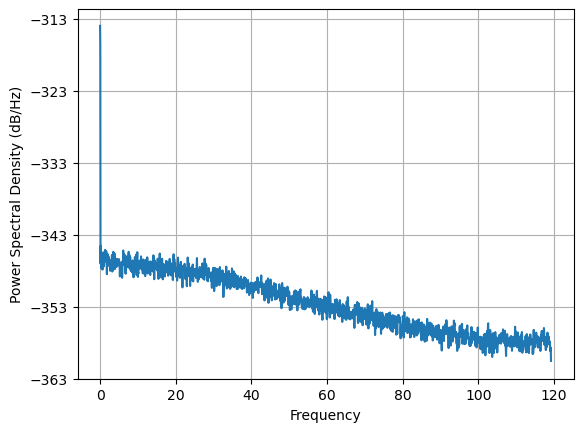

In [35]:
span = 500
NFFT=2**12
time = dt *  np.linspace(index- span, index + span, 2*span)
iq = Analysis_functions.retrieve_IQ_td(file_name)
i_data = iq[ai, ch, 0, :]
q_data = iq[ai, ch, 1, :]
r_data = np.sqrt(i_data **2 + q_data**2)
freqs, Sx, Sy, Sr = Analysis_functions.psd_from_IQ_td(iq, Fs, NFFT=NFFT)
f_res[ai, ch], Qs[ai,ch] = Analysis_functions.lorentzian_fit_thermalpeak_bis_onlyFandQ(Sx[ai,ch,:], freqs[ai,ch,:], fdemods[ai,ch], ai, ch, Plot=False)
kappa = np.sqrt(fdemods[ai,ch]*2*np.pi*meff[ch]/(Qs[ai,ch]*Rbaw[ai,ch]))
strain = Analysis_functions.R_to_strain(r_data[:], Fs, fdemods[ai,ch], Vphi[ai], Min[ai], kappa)
T = 0.5*(fdemods[ai, ch]*2*np.pi)**2*meff[ch]*strain**2/k
tau = Qs[ai,ch] /np.pi / f_res[ai,ch]
Nfilter=int(Fs*20*1) # assume 1s tau
t_sig =1/Fs*np.linspace(0, Nfilter, Nfilter)
template = np.exp(-t_sig/(2*tau)) # template construction
#template = exp_rise_decay(t_sig, A=1.0, t0=0.0, tau_r = 0.001, tau_d=tau/2)
SNR, filtered_strain = Analysis_functions.optimal_filter(strain, template, Fs, NFFT)
T_filtered = 0.5*(fdemods[ai, ch]*2*np.pi)**2*meff[ch]*np.abs(filtered_strain)**2/k

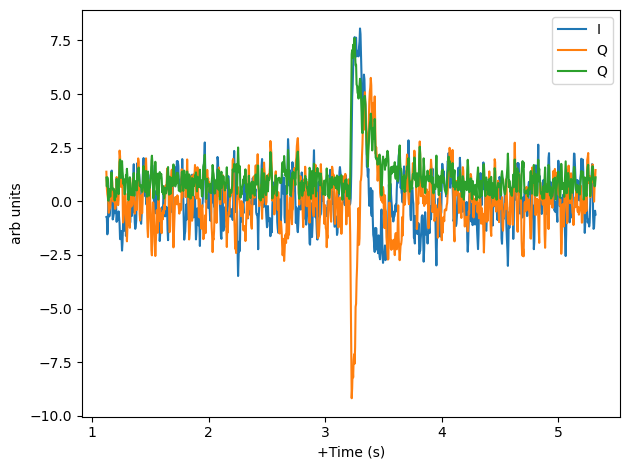

In [36]:

plt.plot(time, i_data[index-span:index+span]/np.sqrt(np.mean(i_data**2)), label = 'I')
plt.plot(time, q_data[index-span:index+span]/np.sqrt(np.mean(q_data**2)), label = 'Q')
plt.plot(time, r_data[index-span:index+span]/np.sqrt(np.mean(r_data**2)), label = 'Q')


plt.legend(loc=0)
#plt.title(date + 'f = %1.2f MHz Detector %1i SNR of %1.2f' % (f_demod/1e6, AI, np.max(SNR1)))
plt.xlabel('+Time (s)')
plt.ylabel('arb units')
plt.tight_layout()
pp = r'C:/Users\00103619\GitHub\MAGE-Data-Analysis\MAGE\MAGE4\analysis results\plots\28thDec2025-2-SNR-all-modes.pdf'
#plt.savefig(pp, format='pdf', dpi=600)

c:\Users\00103619\GitHub\MAGE-Data-Analysis\MAGE\MAGE4\Analysis_functions.py:40: RuntimeWarning: invalid value encountered in divide
  SNR = np.abs(2*dat_filt) / (sigma)


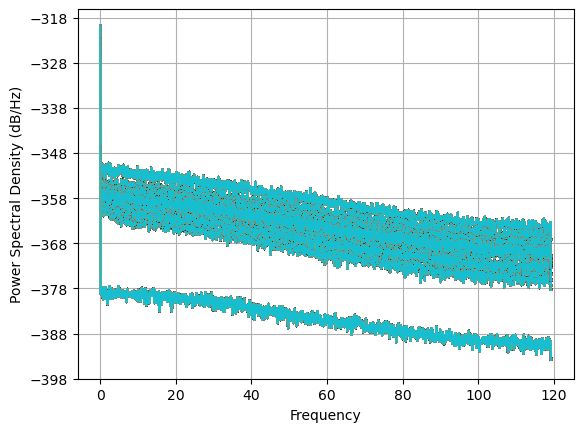

In [21]:
ai = 0
Ntemplates = 20
SNR_arr = np.zeros((16,Ntemplates, Ntemplates))
T_arr = []
nn=index
for ch in range(16):
    iq = Analysis_functions.retrieve_IQ_td(file_name)
    i_data = iq[ai, ch, 0, :]
    q_data = iq[ai, ch, 1, :]
    r_data = np.sqrt(i_data **2 + q_data**2)
    freqs, Sx, Sy, Sr = Analysis_functions.psd_from_IQ_td(iq, Fs, NFFT=NFFT)
    f_res[ai, ch], Qs[ai,ch] = Analysis_functions.lorentzian_fit_thermalpeak_bis_onlyFandQ(Sx[ai,ch,:], freqs[ai,ch,:], fdemods[ai,ch], ai, ch, Plot=False)
    kappa = np.sqrt(fdemods[ai,ch]*2*np.pi*meff[ch]/(Qs[ai,ch]*Rbaw[ai,ch]))
    strain = Analysis_functions.R_to_strain(r_data[:], Fs, fdemods[ai,ch], Vphi[ai], Min[ai], kappa)
    tau = Qs[ai,ch] /np.pi / f_res[ai,ch]
    Nfilter=int(Fs*10*tau)
    t_sig = 1/Fs*np.linspace(0, Nfilter, Nfilter)
    #template = np.exp(-t_sig/(2 * tau)) # template construction
    tau_vec_rise = 1.0*np.logspace(-4,1,Ntemplates)
    tau_vec_decay = tau*np.logspace(-2,2,Ntemplates)
    for j in range(Ntemplates):
        for i in range(Ntemplates):
            template = exp_rise_decay(t_sig, A=1.0, t0=0.0, tau_r = tau_vec_rise[j], tau_d=tau_vec_decay[i])
            SNR, filtered_strain = Analysis_functions.optimal_filter(strain, template, Fs, NFFT)
            SNR_arr[ch,j,i] = np.max(SNR[nn])

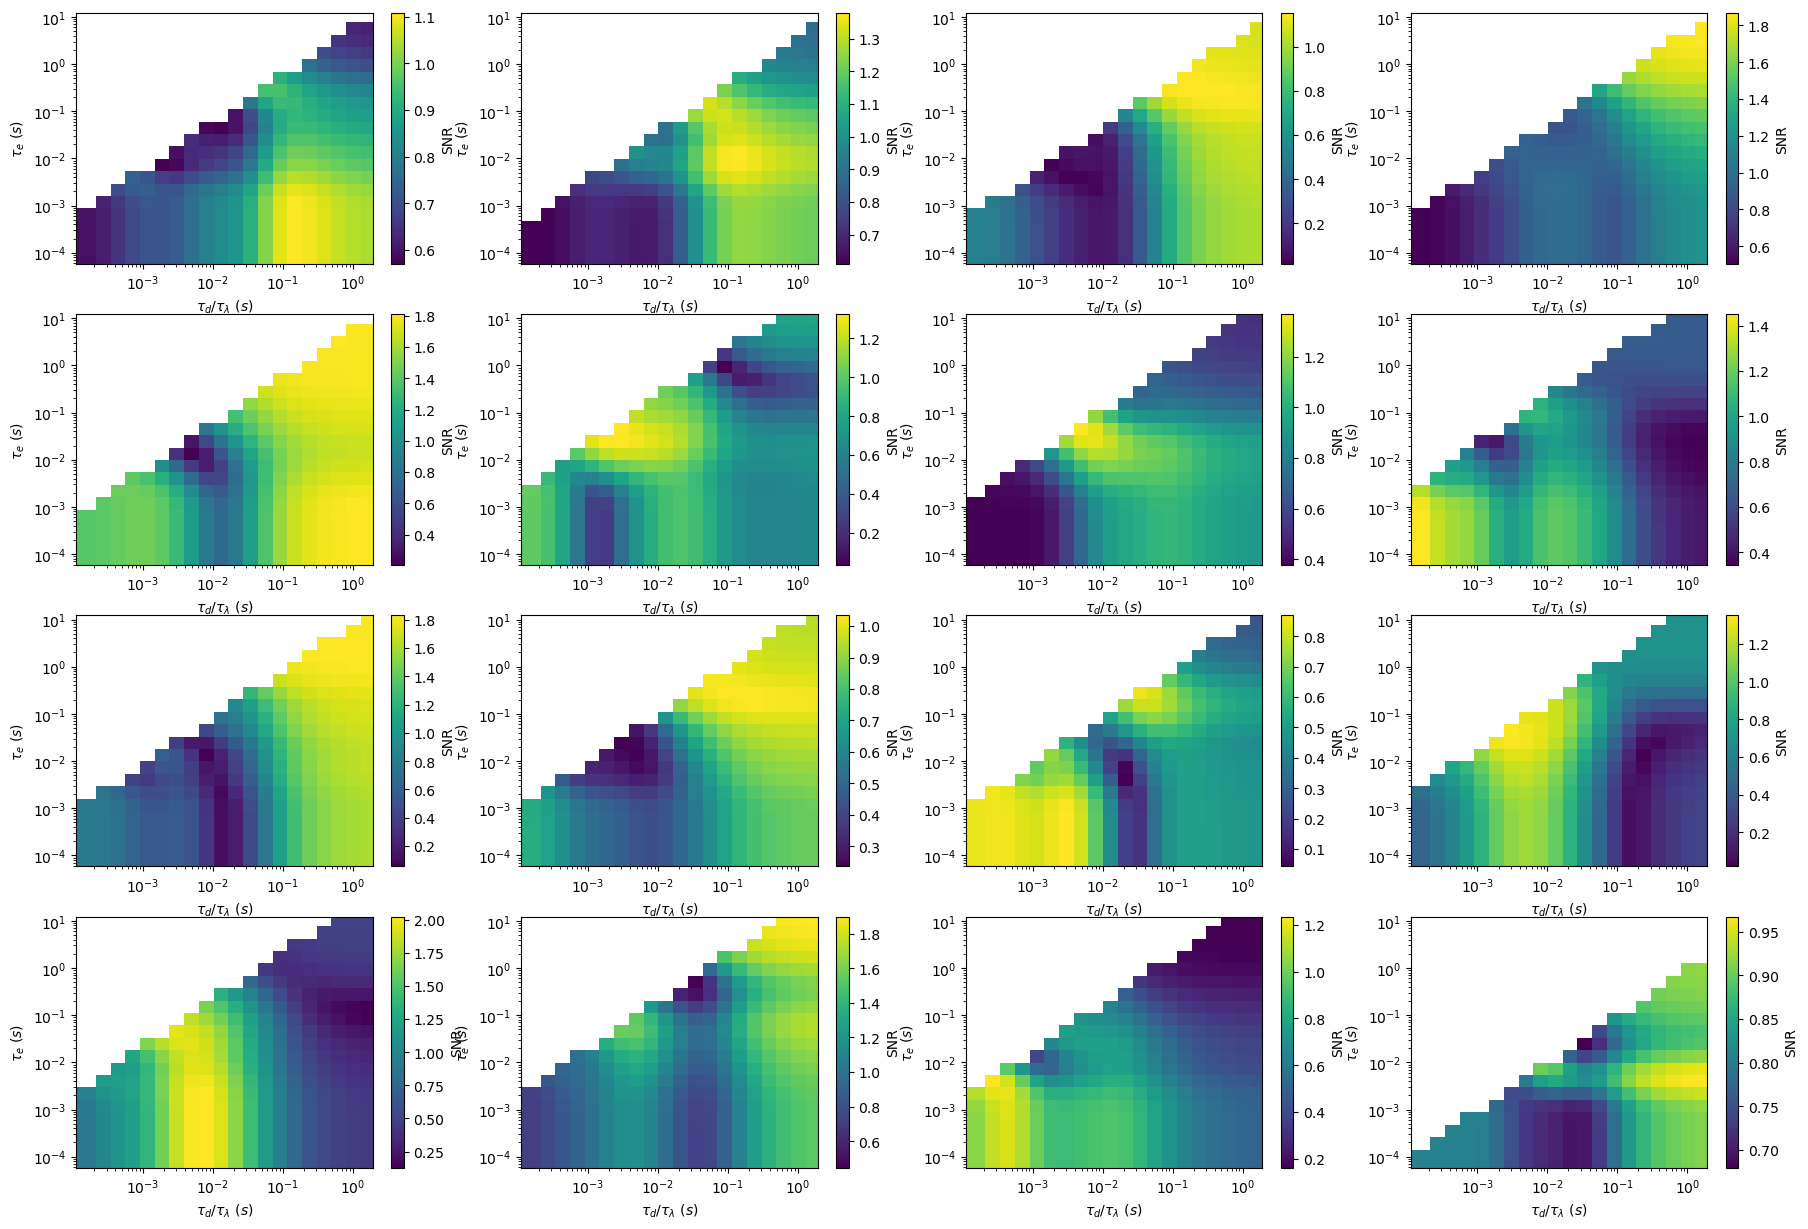

In [23]:
XX, YY = np.meshgrid(tau_vec_decay, tau_vec_rise)
fig, ax = plt.subplots(4,4, figsize=(22,15))
for i in range(4):
    for j in range(4):
        ZZ = (SNR_arr[i*4+j,:,:])
        im = ax[i][j].pcolormesh(XX,YY, ZZ, cmap='viridis')
        fig.colorbar(im, ax=ax[i, j], label = 'SNR')
        ax[i][j].set_yscale('log')
        ax[i][j].set_xscale('log')
        ax[i][j].set_ylabel(r'$\tau_e~(s)$')
        ax[i][j].set_xlabel(r'$\tau_d/\tau_\lambda~(s)$')
        #ax[i][j].set_colorbar(label = 'max. SNR')
pp = '20250325-template-two-tau-normalised.pdf'
#plt.savefig(pp, format='pdf', dpi=600)

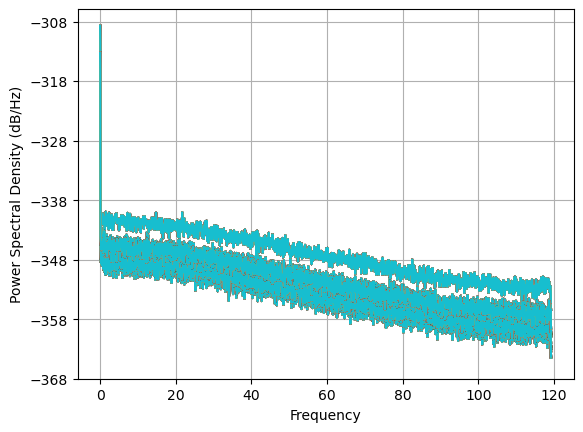

In [37]:
#nn = 172525
ai = 1
Ntemplates = 50
SNR_arr = np.zeros((16,Ntemplates, 2*span))
T_arr = []
nn=index
for ch in range(16):
    iq = Analysis_functions.retrieve_IQ_td(file_name)
    i_data = iq[ai, ch, 0, :]
    q_data = iq[ai, ch, 1, :]
    r_data = np.sqrt(i_data **2 + q_data**2)
    freqs, Sx, Sy, Sr = Analysis_functions.psd_from_IQ_td(iq, Fs, NFFT=NFFT)
    f_res[ai, ch], Qs[ai,ch] = Analysis_functions.lorentzian_fit_thermalpeak_bis_onlyFandQ(Sx[ai,ch,:], freqs[ai,ch,:], fdemods[ai,ch], ai, ch, Plot=False)
    kappa = np.sqrt(fdemods[ai,ch]*2*np.pi*meff[ch]/(Qs[ai,ch]*Rbaw[ai,ch]))
    strain = Analysis_functions.R_to_strain(r_data[:], Fs, fdemods[ai,ch], Vphi[ai], Min[ai], kappa)
    tau = Qs[ai,ch] /np.pi / f_res[ai,ch]
    Nfilter=int(Fs*10*tau)
    t_sig = 1/Fs*np.linspace(0, Nfilter, Nfilter)
    template = np.exp(-t_sig/(2 * tau)) # template construction
    tau_vec = tau*np.logspace(-3,3,Ntemplates)
    for i in range(Ntemplates):
        template = np.exp(-t_sig/(tau_vec[i]))
        #template = np.exp(t_sig*(tau_vec[i]))
        SNR, filtered_strain = Analysis_functions.optimal_filter(strain, template, Fs, NFFT)
        SNR_arr[ch,i,:] = SNR[nn-span:nn+span]

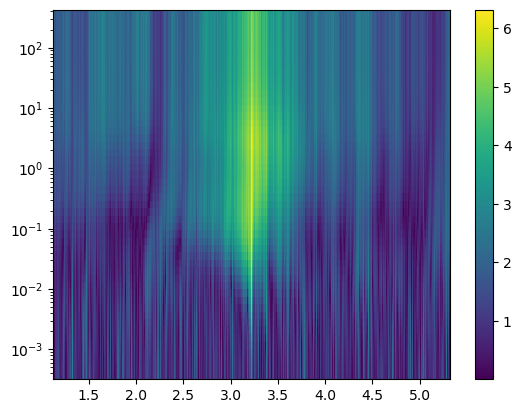

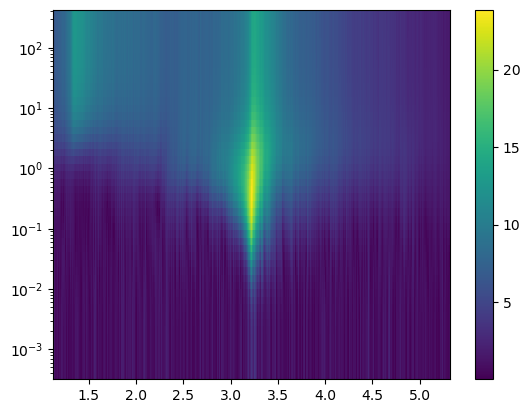

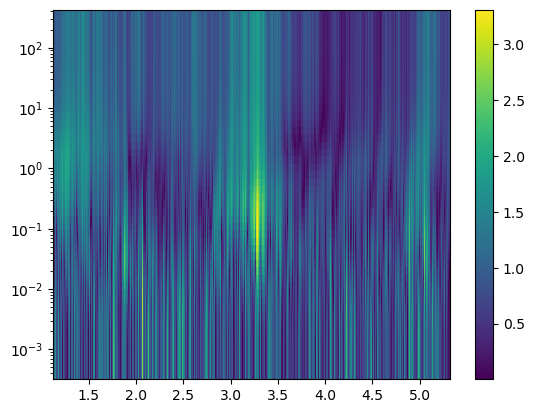

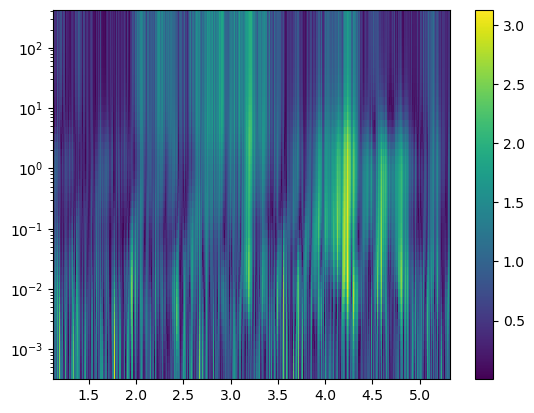

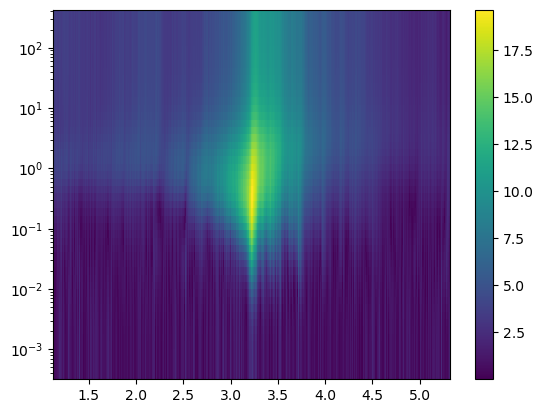

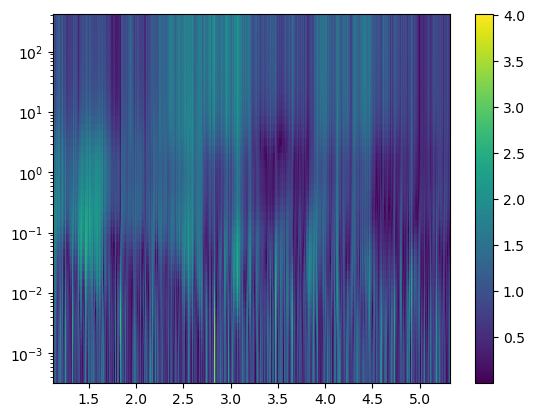

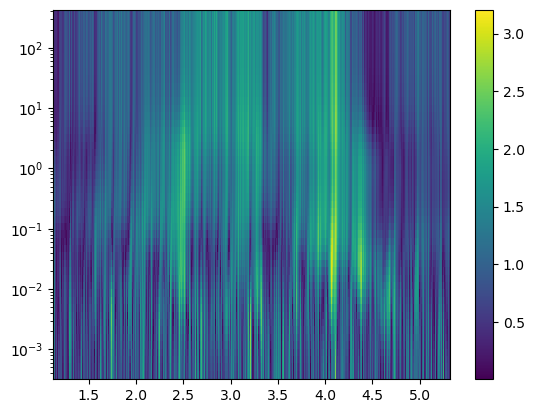

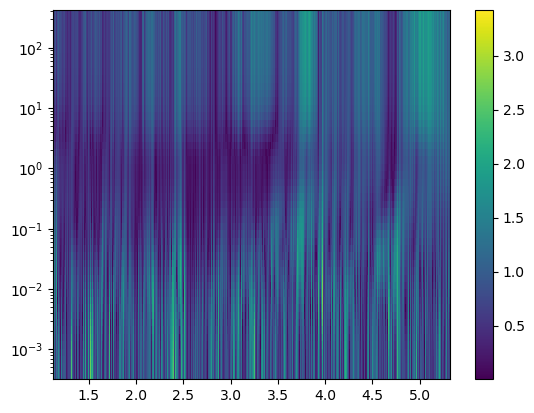

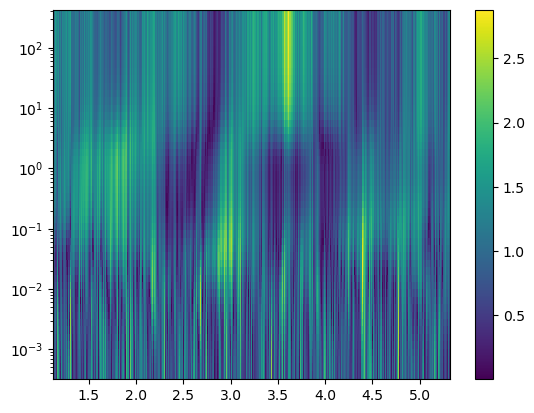

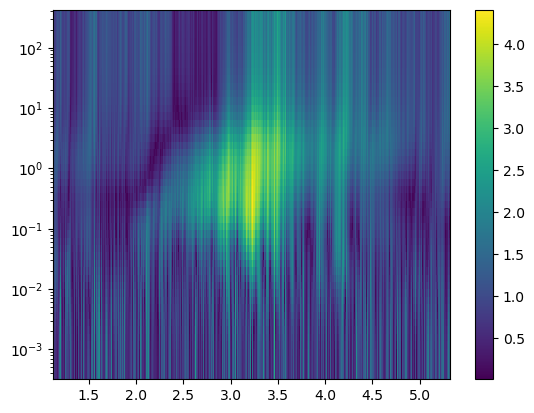

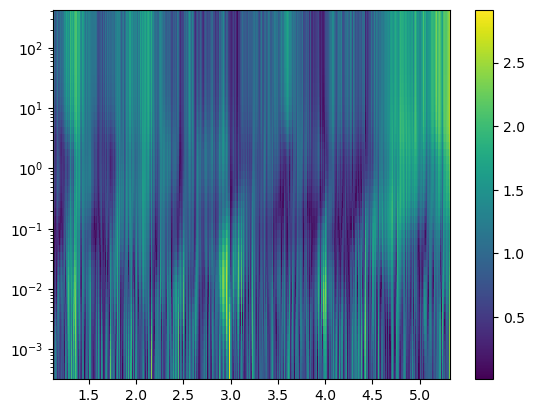

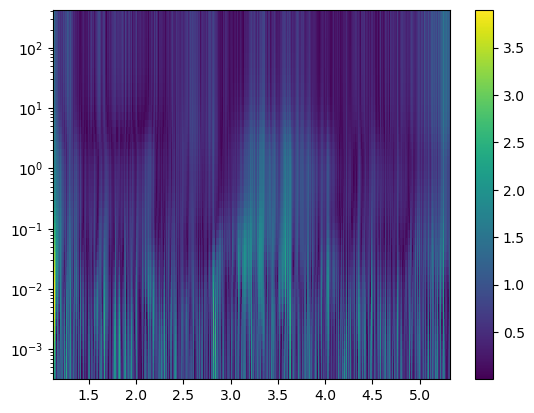

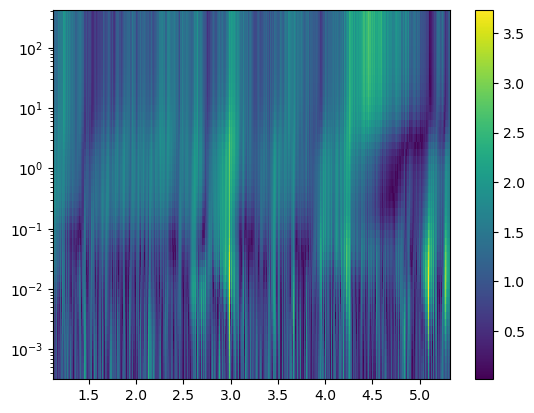

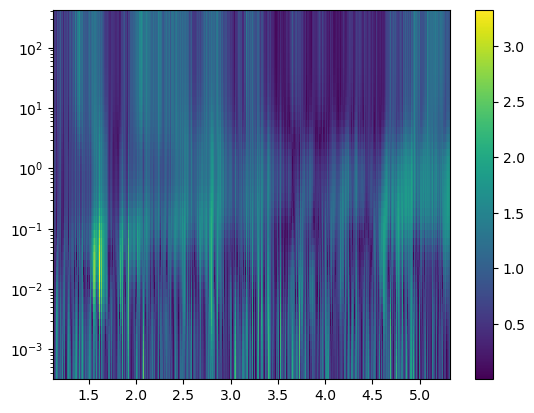

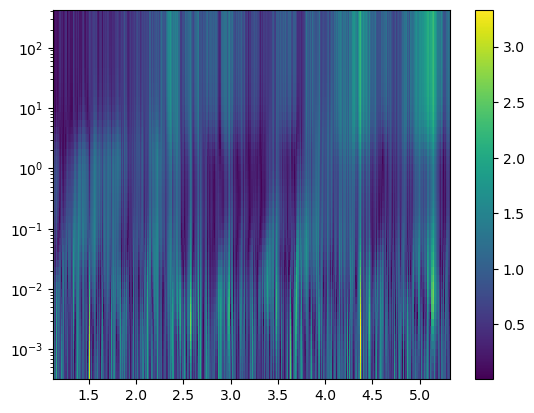

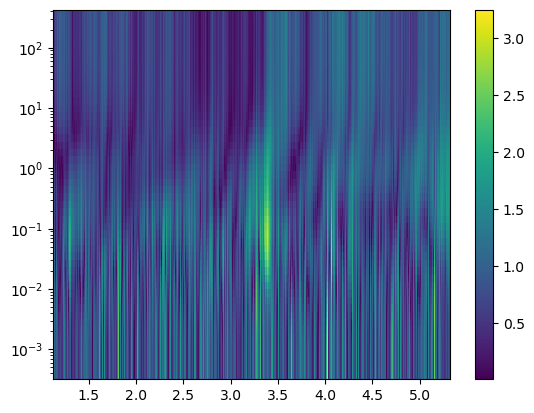

In [38]:
XX, YY = np.meshgrid(time, tau_vec)
for i in range(16):
    ZZ = SNR_arr[i,:]
    plt.pcolormesh(XX,YY, ZZ, cmap='viridis')
    plt.yscale('log')
    plt.colorbar()
    plt.show() 

In [560]:
from scipy.stats import chi2
Nbins=10000

In [91]:
df, loc, scale = chi2.fit([t for t in T if t < 20], f0=2)
df, loc2, scale2 = chi2.fit([t for t in T_filtered if t < 20], f0=2)

In [92]:
tn_T = np.linspace(0, 5, Nbins)

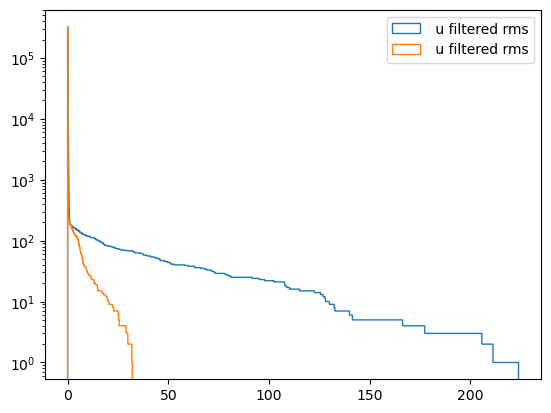

In [595]:
plt.hist(T, bins=50000, label = ' u filtered rms', density=False, cumulative=-1, histtype='step')
plt.hist(np.abs(T_filtered), bins=50000, label = ' u filtered rms', density=False, cumulative=-1, histtype='step')
#plt.plot(tn_T, chi2.pdf(tn_T, df, loc=loc, scale=scale), label = r'$T_\mathrm{th} = %1.1f K$' % (2*scale))
#plt.plot(tn_T, chi2.pdf(tn_T, df, loc=loc2, scale=scale2), label = r'$T_\mathrm{eff} = %1.1f mK$' % (2*scale2))
#plt.ylim(0.1,1e2)
#plt.xlim(0,10)
plt.yscale('log')
#plt.xscale('log')
plt.legend()

In [29]:
feffective_mass = open(r'C:\Users\00103619\MAGE\MAGE4\calibration/Meff.txt')
mode_distributions = np.genfromtxt(feffective_mass, delimiter=',', skip_header=1)
meff = mode_distributions[:,1]
xi = mode_distributions[:,2]

In [1828]:
ai = 0
ch = 1
file_i = 69   
index=54585

file_name = r'C:\Users\00103619\MAGE\MAGE4\run11\\' + 'run11-' + str(file_i) + '.hdf5'
iq = Analysis_functions.retrieve_IQ_td(file_name)

In [2089]:
t_sig = dt*np.linspace(0,800,800)
fr=2.0
tr = 300e-3
sim_sigX = 5.0 *np.sin(fr*t_sig*2*np.pi)* (np.exp(-t_sig / tau) - np.exp(-t_sig / tr)) + np.random.normal(scale = 0.1, size=800)
sim_sigY =5.0 *np.sin(fr*t_sig*2*np.pi + 0.55*np.pi)* (np.exp(-t_sig / tau) - np.exp(-t_sig / tr)) + np.random.normal(scale = 0.1, size=800)

sim_sigR = np.sqrt(sim_sigY**2+sim_sigX**2)

def simulated_signal(t, fr, phi_shift, tau_r, tau_d):
    return np.sin(fr*t*2*np.pi + phi_shift)*exp_rise_decay(t, A=1.0, t0=t[-1]//4, tau_r=tau_r, tau_d=tau_d) + np.random.normal(scale = 0.01, size=2*span)
    

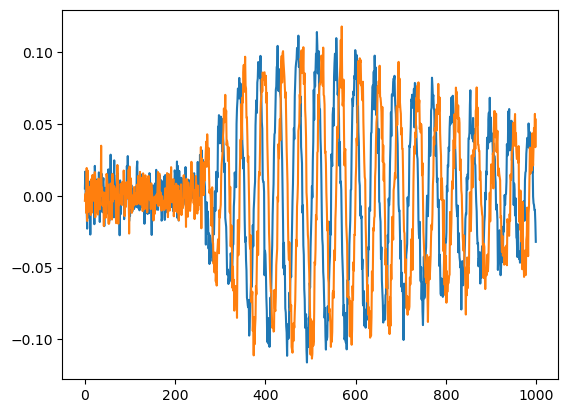

In [2129]:
plt.plot(signal_q)
plt.plot(signal_i)

C:\Users\00103619\AppData\Local\Temp\ipykernel_23536\983288795.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i][j].legend()


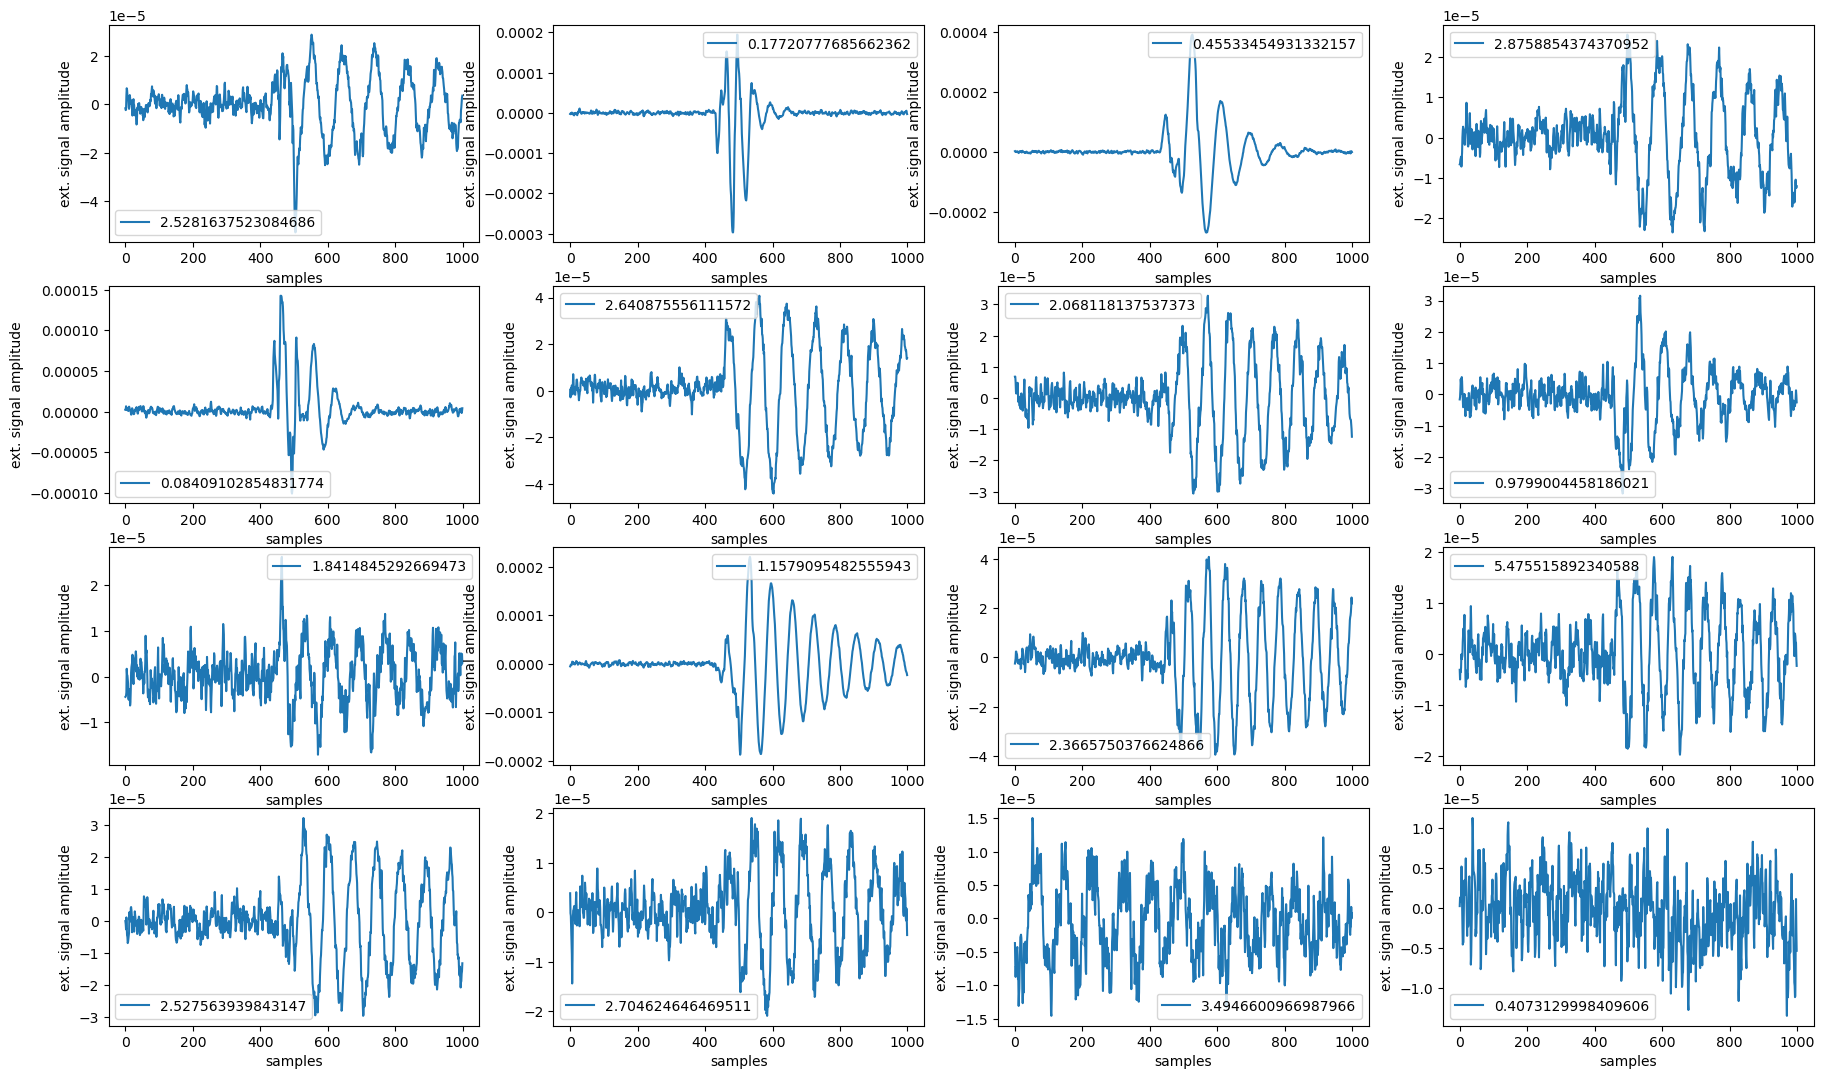

In [2147]:
fig, ax = plt.subplots(4,4, figsize = (22,13))
ai=1
span=500
out=[]
for i in range(4):
    for j in range(4):
        ch =  i*4+j
        i_data = iq[ai, ch, 0, :]
        q_data = iq[ai, ch, 1, :]
        tsig = dt*(np.linspace(0, 2*span,2*span))
        signal_i = i_data[index-span:index+span]
        signal_q = q_data[index-span:index+span]

        fr = f_res[ai, ch] - fdemods[ai, ch]
        tau = Qs[ai,ch] /np.pi / f_res[ai,ch]

        # signal_i = simulated_signal(tsig, fr, 0.0, 900e-3, tau)
        # signal_q = simulated_signal(tsig, fr, 0.5*np.pi, 900e-3, tau)

        s_fft_i = np.fft.rfft(signal_i)
        s_fft_q = np.fft.rfft(signal_q)
        fft_freqs = np.fft.rfftfreq(len(signal_i), d=dt)
        Hlock = (1+1j*(fft_freqs/38))**(-1)
        Hquartz = ((-2*np.pi*fft_freqs)**2/2*1.093e-3*xi[ch])/((2j*np.pi*fft_freqs)**2+tau**(-1)*2j*np.pi*fft_freqs + (2*np.pi*fr)**2)
        Hiw = Hlock*Hquartz
        alpha = 1e-9
        Hreg = np.conjugate(Hiw)/(np.abs(Hiw)**2+alpha)
        out_i = np.fft.ifft(s_fft_i[1:]*Hreg[1:]*np.hanning(len(Hreg[1:])))
        out_q = np.fft.ifft(s_fft_q[1:]*Hreg[1:]*np.hanning(len(Hreg[1:])))
        # ax[i][j].plot(fft_freqs[1:], np.abs(s_fft_i[1:]/Hiw[1:]), label = r'$S_h^+(f)$')
        # ax[i][j].plot(fft_freqs[1:], np.abs(s_fft_q[1:]/Hiw[1:]), label = r'$S_h^+(f)$')
        # ax[i][j].plot(fft_freqs[1:], np.abs(1/Hiw[1:]), label = r'$S_h^+(f)$')
        # ax[i][j].set_yscale('log')
        # ax[i][j].set_xscale('log')

        # ax[i][j].plot(np.abs(out_i), label = '|I|')
        # ax[i][j].plot(np.abs(out_q), label = '|Q|')
    
        ax[i][j].set_xlabel('samples')
        ax[i][j].set_ylabel('ext. signal amplitude')
        ax[i][j].legend()
        R = signal_i**2+signal_q**2
        ax[i][j].plot(signal_i, label = str(tau))
        ax[i][j].legend()
        # print(str(f_res[ai,ch]) + ', ' + str(np.where(R == np.max(R))[0][0]))
        # out.append(np.where(R == np.max(R))[0][0])
# pp = 'BAW20250325-det2.pdf'
# plt.savefig(pp, format='pdf', dpi=600)

In [2118]:
Qs[0,:]/1e6

array([15.229782,  0.698836,  2.651382, ..., 43.592998, 64.130562,
       58.511713])

In [1617]:
ai = 0
ch = 1
file_i = 124   
index=179051

file_name = r'C:\Users\00103619\MAGE\MAGE4\run9\\' + 'run9-' + str(file_i) + '.hdf5'
iq = Analysis_functions.retrieve_IQ_td(file_name)

In [1960]:
ai = 0
ch = 1
file_i = 69   
index=54585

file_name = r'C:\Users\00103619\MAGE\MAGE4\run11\\' + 'run11-' + str(file_i) + '.hdf5'
iq = Analysis_functions.retrieve_IQ_td(file_name)

C:\Users\00103619\AppData\Local\Temp\ipykernel_14408\1943382569.py:16: RuntimeWarning: invalid value encountered in scalar divide
  tau = Qs[ai,ch] /np.pi / f_res[ai,ch]
C:\Users\00103619\AppData\Local\Temp\ipykernel_14408\1943382569.py:21: RuntimeWarning: invalid value encountered in divide
  Hquartz = ((-2*np.pi*fft_freqs)**2/2*1.093e-3*xi[ch])/((2j*np.pi*fft_freqs)**2+tau**(-1)*2j*np.pi*fft_freqs + (2*np.pi*fr)**2)
C:\Users\00103619\AppData\Local\Temp\ipykernel_14408\1943382569.py:24: RuntimeWarning: invalid value encountered in divide
  Hreg = np.conjugate(Hiw)/(np.abs(Hiw)**2+alpha)
C:\Users\00103619\AppData\Local\Temp\ipykernel_14408\1943382569.py:25: RuntimeWarning: invalid value encountered in divide
  out_i = np.fft.ifft(s_fft_i[1:]/Hiw[1:]*np.hanning(len(Hreg[1:])))
C:\Users\00103619\AppData\Local\Temp\ipykernel_14408\1943382569.py:26: RuntimeWarning: invalid value encountered in divide
  out_q = np.fft.ifft(s_fft_q[1:]/Hiw[1:]*np.hanning(len(Hreg[1:])))


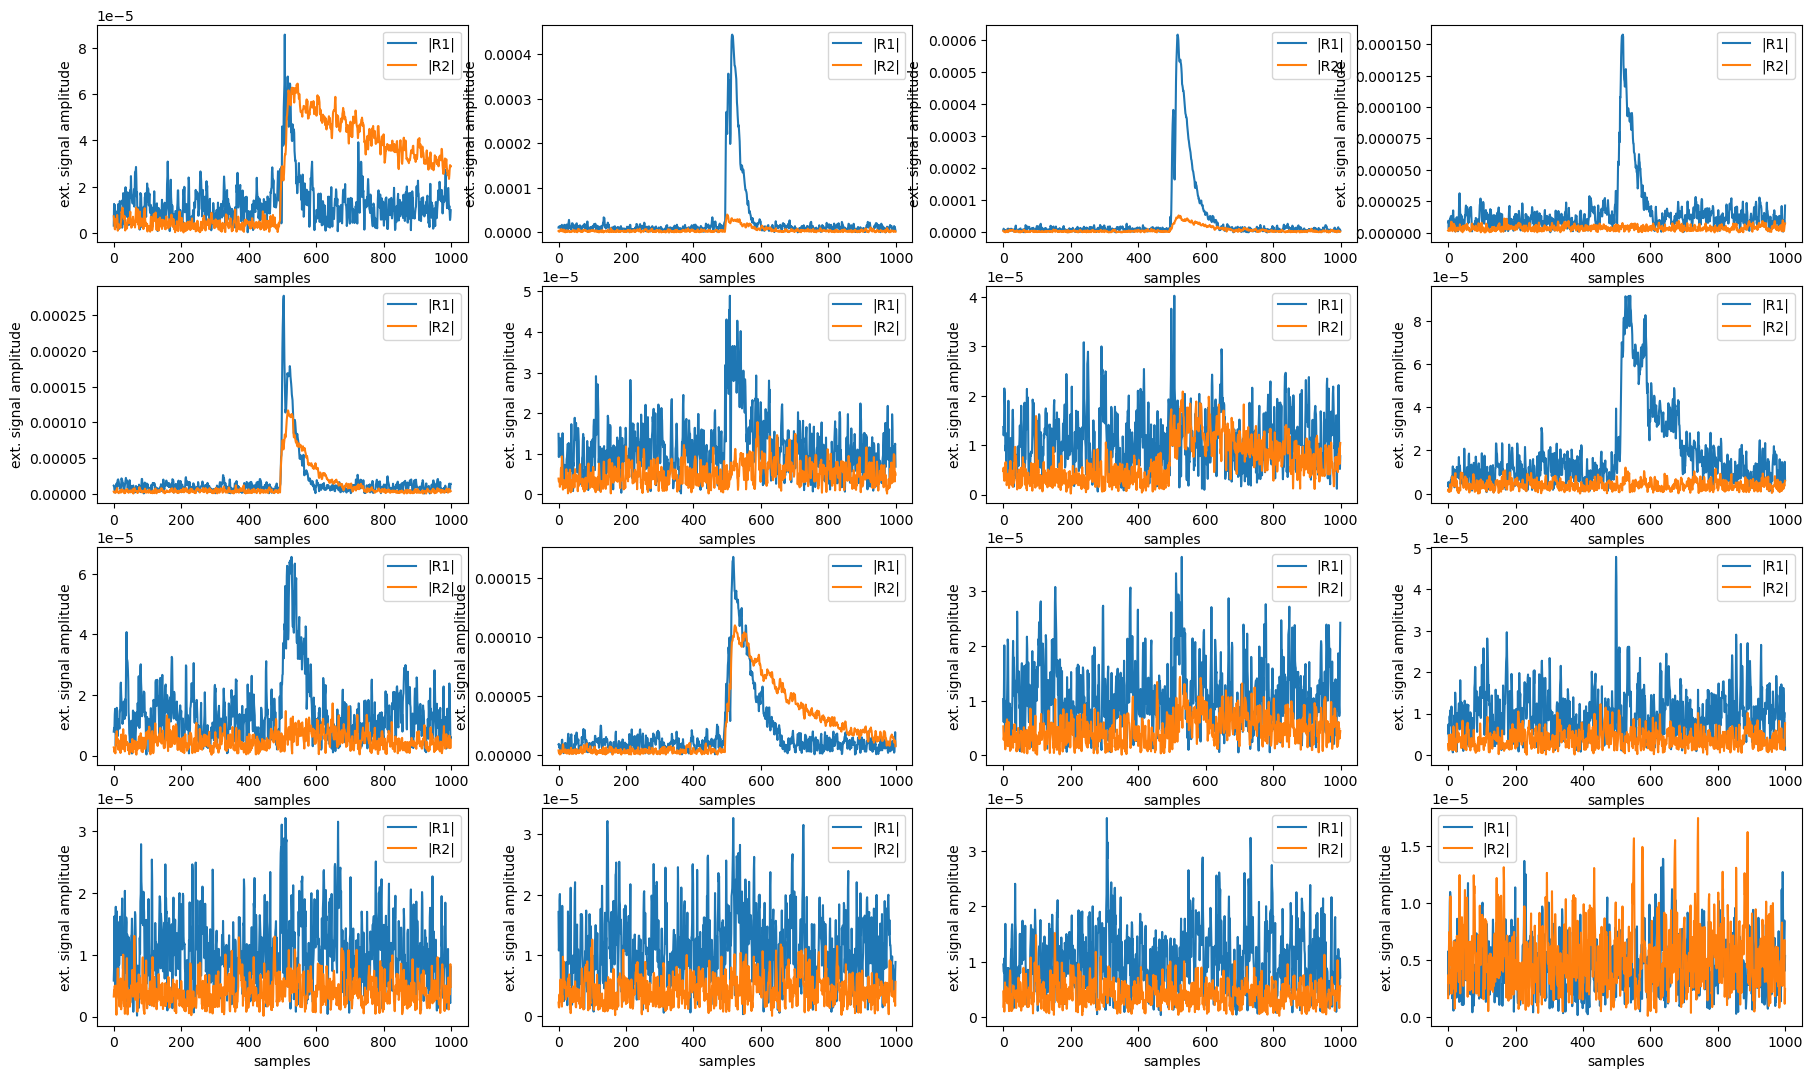

In [114]:
fig, ax = plt.subplots(4,4, figsize = (22,13))
ai=0
span=500
for i in range(4):
    for j in range(4):
        ch =  i*4+j
        i_data = iq[0, ch, 0, :]
        q_data = iq[0, ch, 1, :]
        i_data2 = iq[1, ch, 0, :]
        q_data2 = iq[1, ch, 1, :]
        signal_i = i_data[index-span:index+span]
        signal_q = q_data[index-span:index+span]
        signal_2q = q_data2[index-span:index+span]
        signal_2i = i_data2[index-span:index+span]
        fr = f_res[ai, ch] - fdemods[ai, ch]
        tau = Qs[ai,ch] /np.pi / f_res[ai,ch]
        s_fft_i = np.fft.rfft(signal_i)
        s_fft_q = np.fft.rfft(signal_q)
        fft_freqs = np.fft.rfftfreq(len(signal_i), d=dt)
        Hlock = (1+1j*(fft_freqs/38))**(-1)
        Hquartz = ((-2*np.pi*fft_freqs)**2/2*1.093e-3*xi[ch])/((2j*np.pi*fft_freqs)**2+tau**(-1)*2j*np.pi*fft_freqs + (2*np.pi*fr)**2)
        Hiw = Hlock*Hquartz
        alpha = 1e-3
        Hreg = np.conjugate(Hiw)/(np.abs(Hiw)**2+alpha)
        out_i = np.fft.ifft(s_fft_i[1:]/Hiw[1:]*np.hanning(len(Hreg[1:])))
        out_q = np.fft.ifft(s_fft_q[1:]/Hiw[1:]*np.hanning(len(Hreg[1:])))
        # ax[i][j].plot(fft_freqs[1:], np.abs(s_fft_i[1:]/Hiw[1:]), label = r'$S_h^+(f)$')
        # ax[i][j].set_yscale('log')
        # ax[i][j].set_xscale('log')


        #ax[i][j].plot(out_q.real, label = 'real(Q)')
        ax[i][j].plot(np.sqrt(signal_q**2+signal_i**2), label = '|R1|')
        ax[i][j].plot(np.sqrt(signal_2q**2+signal_2i**2), label = '|R2|')
        #ax[i][j].plot(np.abs(out_q), label = '|Q|')
        ax[i][j].set_xlabel('samples')
        ax[i][j].set_ylabel('ext. signal amplitude')
        ax[i][j].legend()
#pp = 'BCK20250315.pdf'
#plt.savefig(pp, format='pdf', dpi=600)

In [2325]:
f.close()

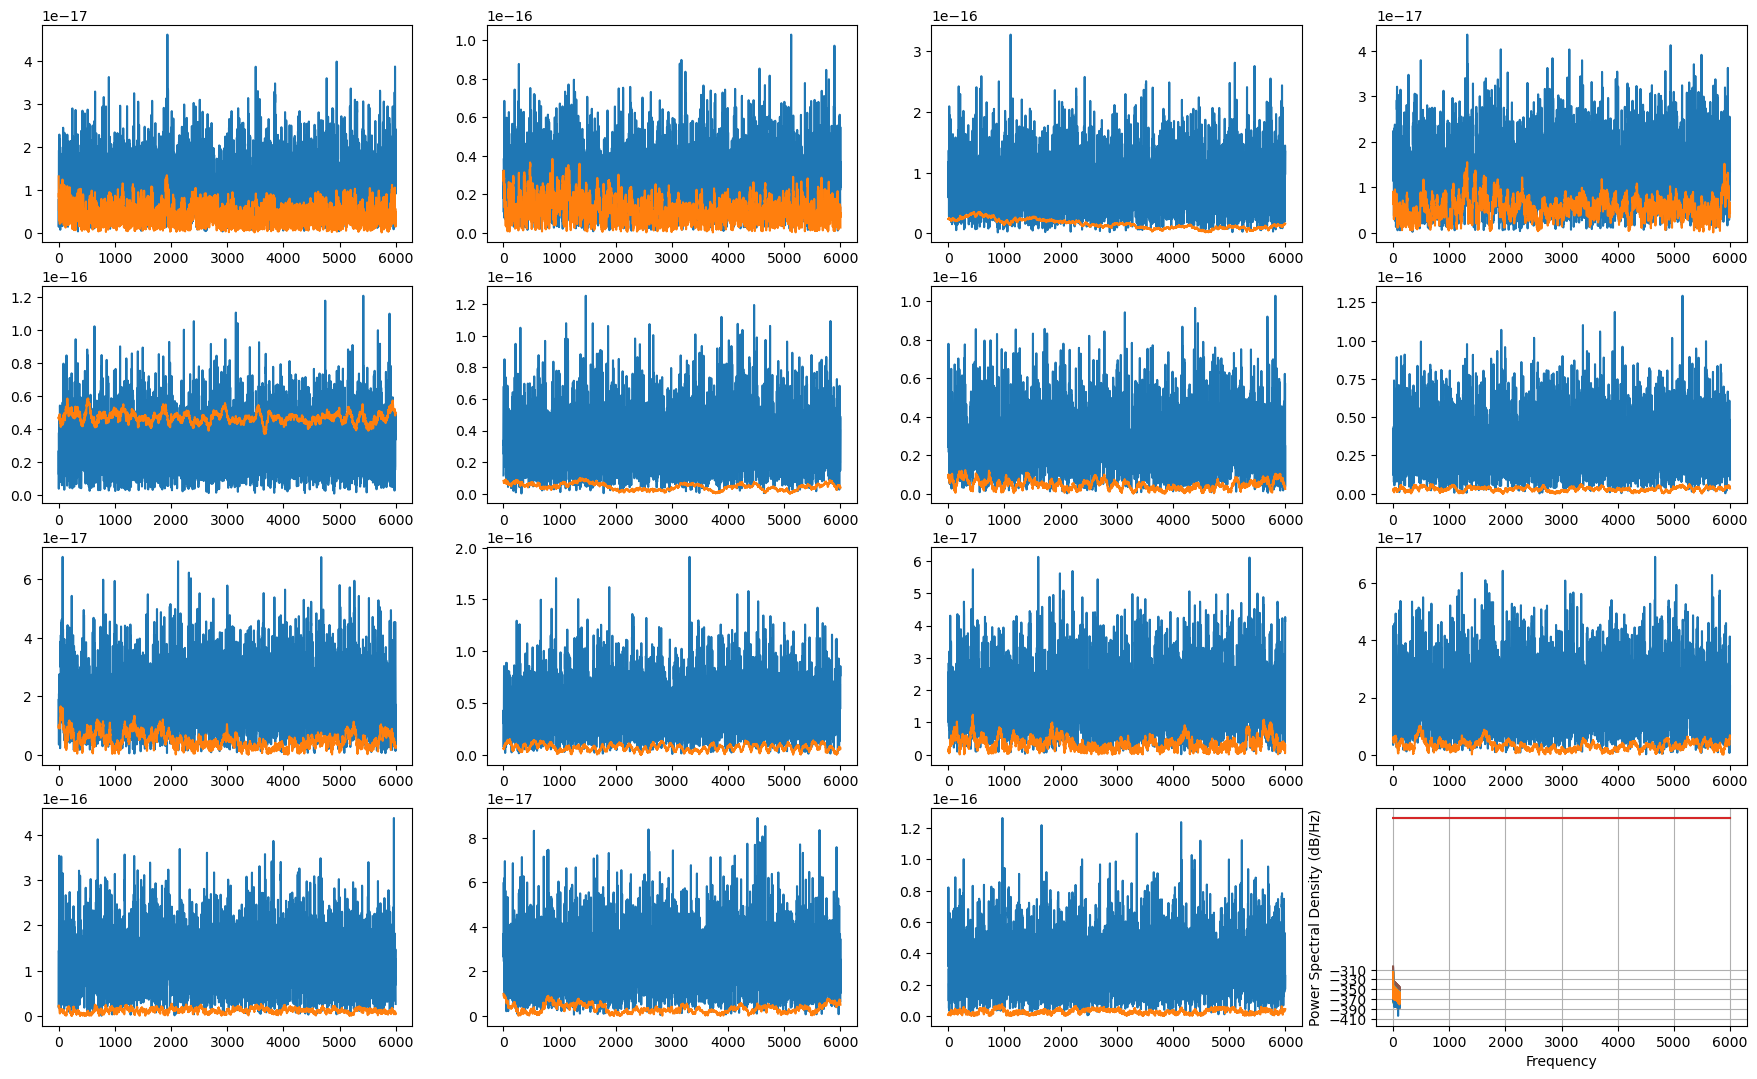

In [2324]:
fig, ax = plt.subplots(4,4, figsize = (22,13))
span=3000
freqs, Sx, Sy, Sr = Analysis_functions.psd_from_IQ_td(iq, Fs, NFFT=NFFT)
for i in range(4):
    for j in range(4):
        ch =  i*4+j
        i_data = iq[0, ch, 0, :]
        q_data = iq[0, ch, 1, :]
        i_data2 = iq[1, ch, 0, :]
        q_data2 = iq[1, ch, 1, :]
        r_data, r_data2 = np.sqrt(i_data**2+q_data**2), np.sqrt(i_data2**2+q_data2**2)
        f_res[0, ch], Qs[0,ch] = Analysis_functions.lorentzian_fit_thermalpeak_bis_onlyFandQ(Sx[0,ch,:], freqs[0,ch,:], fdemods[0,ch], 0, ch, Plot=False)
        f_res[1, ch], Qs[1,ch] = Analysis_functions.lorentzian_fit_thermalpeak_bis_onlyFandQ(Sx[1,ch,:], freqs[1,ch,:], fdemods[1,ch], 1, ch, Plot=False)
        kappa = np.sqrt(fdemods[0,ch]*2*np.pi*meff[ch]/(Qs[0,ch]*Rbaw[0,ch]))
        kappa2 = np.sqrt(fdemods[1,ch]*2*np.pi*meff[ch]/(Qs[1,ch]*Rbaw[1,ch]))
        strain = Analysis_functions.R_to_strain(r_data[:], Fs, fdemods[0,ch], Vphi[0], Min[0], kappa)
        strain2 = Analysis_functions.R_to_strain(r_data2[:], Fs, fdemods[1,ch], Vphi[1], Min[1], kappa)
        tau, tau2 = Qs[0,ch] /np.pi / f_res[0,ch],  Qs[1,ch] /np.pi / f_res[1,ch]
        template, template2 = exp_rise_decay(t_sig, A=1.0, t0=0.0, tau_r = 0.01, tau_d=2*tau), exp_rise_decay(t_sig, A=1.0, t0=0.0, tau_r = 0.01, tau_d=2*tau2)
        #template, template2 = np.exp(-t_sig/(2*tau)) , np.exp(-t_sig/(2*tau2)) # template construction
        SNR, filtered_strain = Analysis_functions.optimal_filter(strain, template, Fs, NFFT)
        SNR2, filtered_strain2 = Analysis_functions.optimal_filter(strain2, template2, Fs, NFFT)
        ax[i][j].plot(strain[index-span:index+span])
        ax[i][j].plot(np.abs(filtered_strain)[index-span:index+span])
        

In [2178]:
t_sig = 0.001*np.linspace(0, Nfilter, Nfilter)
signal = 5e-17*np.exp(-t_sig/(tau/4))
template = np.exp(-t_sig/(tau))
zero_pad = np.zeros(strain.size - signal.size) # zero pad template to match data size
template_pad = np.roll(np.append(signal, zero_pad),50000)

h_inject = template_pad + np.abs(np.random.normal(0, 1.66*np.std(strain), size = len(strain)))
h_inject2 = np.abs(np.random.normal(0, 1.66*np.std(strain), size = len(strain)))

In [2150]:
fdemods[0,1]

5080779.0

## Can you correlate two modes ?

In [ ]:
ai = 0
ch = 0
file_i = 687
index=161844

file_name = r'C:\Users\00103619\MAGE\MAGE4\run7\\' + 'run7-' + str(file_i) + '.hdf5'
iq = Analysis_functions.retrieve_IQ_td(file_name)

In [ ]:
span = 700
offset = 0
time = dt *  np.linspace(index-offset- span, index-offset + span, 2*span)
iq = Analysis_functions.retrieve_IQ_td(file_name)
i_data1 = iq[ai, ch, 0, :]
q_data1 = iq[ai, ch, 1, :]
i_data2 = iq[ai, 4, 0, :]
q_data2 = iq[ai, 4, 1, :]
freqs, Sx, Sy, Sr = Analysis_functions.psd_from_IQ_td(iq, Fs, NFFT=NFFT)
f_res[ai, ch], Qs[ai,ch] = Analysis_functions.lorentzian_fit_thermalpeak_bis_onlyFandQ(Sx[ai,ch,:], freqs[ai,ch,:], fdemods[ai,ch], ai, ch, Plot=False, start=1, stop=1300)

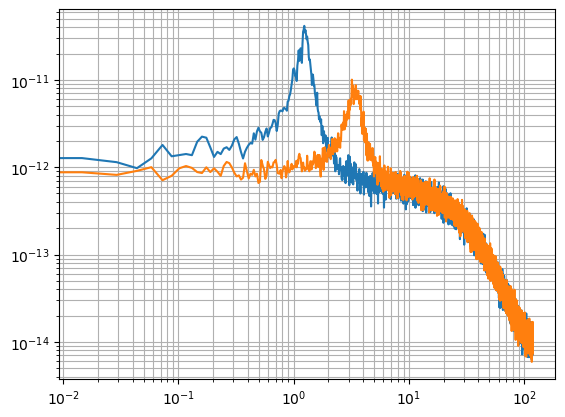

In [ ]:
plt.plot(freqs[ai,ch,:], Sx[ai,ch,:])
plt.plot(freqs[ai,4,:], Sx[ai,4,:])
plt.xscale('log')
plt.yscale('log')
plt.grid(which='both')

In [ ]:
i2_mixed = i_data2*np.cos(2*np.pi*(2.3)*dt *  np.linspace(0, len(i_data2), len(i_data2))) 

i2_filtered = butter_lowpass_filter(i2_mixed, 2, 1/dt, order=2)

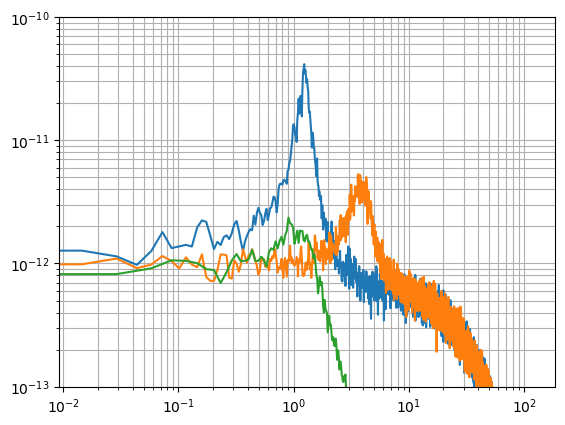

In [ ]:
import scipy
from scipy.signal import welch
fx, Sx2 = scipy.signal.welch(i2_filtered, fs=1/dt, nperseg=NFFT)
plt.plot(freqs[ai,ch,:], Sx[ai,ch,:])
plt.plot(freqs[ai,ch+2,:], Sx[ai,ch+2,:])
plt.plot(fx, Sx2)
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-13,1e-10)
plt.grid(which='both')

(161000.0, 163000.0)

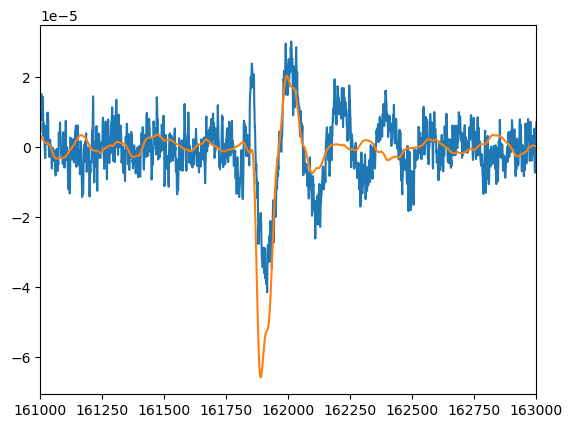

In [ ]:
plt.plot(i_data1)
plt.plot(i2_filtered)
plt.xlim(161000,163000)